In [2]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(tidyr)
library(reshape2)

Warning message:
"package 'Seurat' was built under R version 4.4.3"
Loading required package: SeuratObject

Warning message:
"package 'SeuratObject' was built under R version 4.4.3"
Loading required package: sp

Warning message:
"package 'sp' was built under R version 4.4.3"

Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t



Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.4.3"

Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




##### How can we infer cell types??

Gene expression is the only data available - some genes are 'differentially' expressed in specific cell types.

Should we run cluster-specific cell types? Do each cluster belong to a single cell type?

Hint: Go back to the resolution parameter.

#### Cell type annotation databases and tools

1. Simple canonical markers: Manual (supervised), literature review

2. Reference dataset based: CellMarker 2.0 db, Azimuth

3. ML/DL based: scGPT, scGraph, etc.

In [3]:
pbmc_obj <- readRDS('./pbmc_3k_data/pbmc_3k_clustered.rds')
pbmc_obj

An object of class Seurat 
32738 features across 2634 samples within 1 assay 
Active assay: RNA (32738 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [4]:
all.markers <- FindAllMarkers(object = pbmc_obj)
head(all.markers)

Calculating cluster 0



Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
Warning message:
"`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown o

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
RPS12,3.726769e-129,0.7277209,1.000,0.991,1.220070e-124,0,RPS12
RPS6,8.784061e-117,0.6539921,1.000,0.995,2.875726e-112,0,RPS6
RPS27,2.359049e-112,0.6660097,0.997,0.992,7.723053e-108,0,RPS27
CYBA,3.402733e-112,-1.6719075,0.641,0.916,1.113987e-107,0,CYBA
RPL32,6.095782e-112,0.5785384,0.998,0.995,1.995637e-107,0,RPL32
RPS25,4.991653e-107,0.7277335,0.997,0.976,1.634167e-102,0,RPS25


In [5]:
top5.markers <- all.markers %>%
  group_by(cluster) %>%
  filter(p_val_adj < 0.01) %>%
  slice_max(order_by = avg_log2FC, n = 5)

In [6]:
head(top5.markers)

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
8.215585e-09,7.226556,0.017,0.000,2.689618e-04,0,GTSCR1
6.549376e-09,4.770813,0.021,0.001,2.144135e-04,0,REG4
1.438830e-09,4.571508,0.023,0.001,4.710443e-05,0,C2orf40
1.633724e-10,4.219274,0.033,0.004,5.348485e-06,0,NOG
1.383468e-08,2.893904,0.037,0.007,4.529196e-04,0,LRRN3
1.377449e-08,6.897155,0.015,0.000,4.509492e-04,1,HSD11B1


Warning message:
"The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


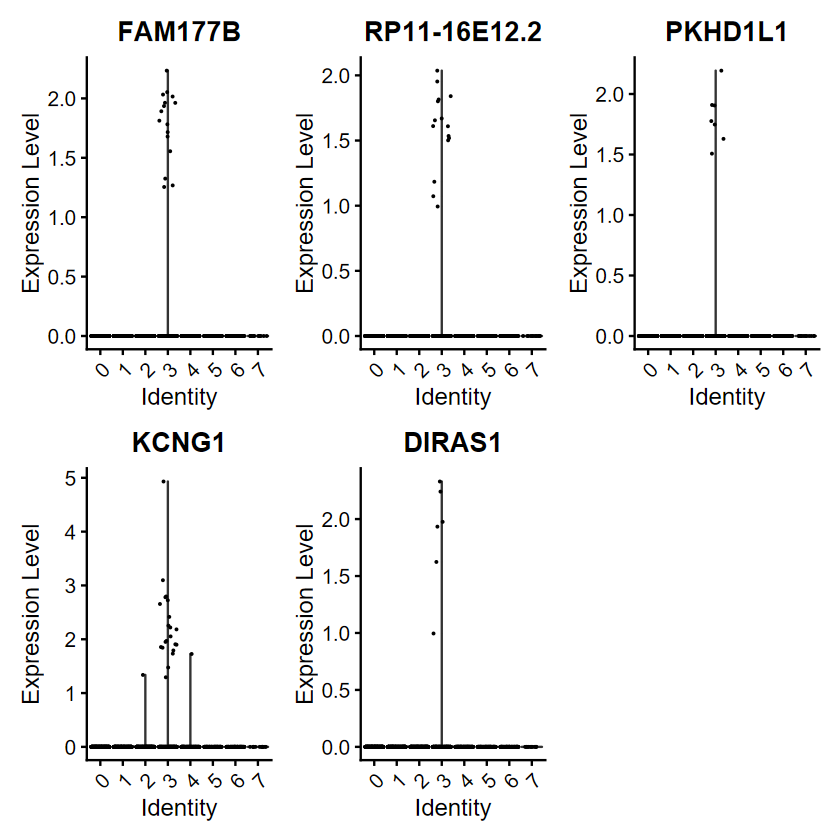

In [7]:
genes_cluster3 <- top5.markers[top5.markers$cluster == 3, ][["gene"]]
VlnPlot(pbmc_obj, features = genes_cluster3) # for cluster 3

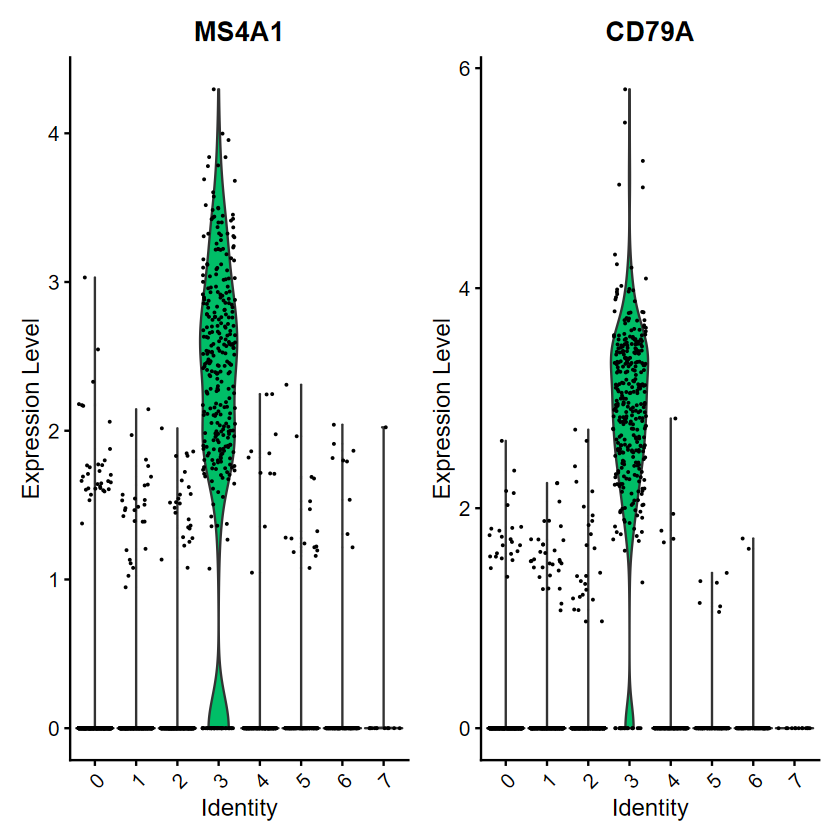

In [8]:
VlnPlot(pbmc_obj, features = c("MS4A1", "CD79A")) # classic B-cell markers

Databases with canonical and curated marker genes for each cell type exist. Example: CellMarker 2.0 (http://bio-bigdata.hrbmu.edu.cn/CellMarker/CellMarker_download.html)

Can we automate the task?

SingleR is an automatic celltype annotation package. It uses a reference dataset, find markers to each cell type in the reference and assign cell type labels based on these markers.

***** Choosing the ideal reference dataset is the key *****

In [9]:
# BiocManager::install("SingleR")
# BiocManager::install("celldex")

In [10]:
library(SingleR)
library(celldex)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats

Warning message:
"package 'matrixStats' was built under R version 4.4.3"

Attaching package: 'matrixStats'


The following object is masked from 'package:dplyr':

    count



Attaching package: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    row

In [11]:
hpca <- HumanPrimaryCellAtlasData()

In [12]:
hpca

class: SummarizedExperiment 
dim: 19363 713 
metadata(0):
assays(1): logcounts
rownames(19363): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(0):
colnames(713): GSM112490 GSM112491 ... GSM92233 GSM92234
colData names(3): label.main label.fine label.ont

In [13]:
head(hpca@colData)

DataFrame with 6 rows and 3 columns
           label.main             label.fine   label.ont
          <character>            <character> <character>
GSM112490          DC DC:monocyte-derived:..  CL:0000840
GSM112491          DC DC:monocyte-derived:..  CL:0000840
GSM112540          DC DC:monocyte-derived:..  CL:0000840
GSM112541          DC DC:monocyte-derived:..  CL:0000451
GSM112661          DC DC:monocyte-derived:..  CL:0000451
GSM112664          DC DC:monocyte-derived:..  CL:0000451

In [14]:
unique(hpca@colData$label.main)

[1] "DC"                   "Smooth_muscle_cells"  "Epithelial_cells"    
 [4] "B_cell"               "Neutrophils"          "T_cells"             
 [7] "Monocyte"             "Erythroblast"         "BM & Prog."          
[10] "Endothelial_cells"    "Gametocytes"          "Neurons"             
[13] "Keratinocytes"        "HSC_-G-CSF"           "Macrophage"          
[16] "NK_cell"              "Embryonic_stem_cells" "Tissue_stem_cells"   
[19] "Chondrocytes"         "Osteoblasts"          "BM"                  
[22] "Platelets"            "Fibroblasts"          "iPS_cells"           
[25] "Hepatocytes"          "MSC"                  "Neuroepithelial_cell"
[28] "Astrocyte"            "HSC_CD34+"            "CMP"                 
[31] "GMP"                  "MEP"                  "Myelocyte"           
[34] "Pre-B_cell_CD34-"     "Pro-B_cell_CD34+"     "Pro-Myelocyte"

In [15]:
expr <- GetAssayData(pbmc_obj, slot = "data")
pred_hesc <- SingleR(test = expr, ref = hpca, assay.type.test=1,
    labels = hpca$label.main)

In [16]:
head(pred_hesc)

DataFrame with 6 rows and 4 columns
                                          scores      labels delta.next
                                        <matrix> <character>  <numeric>
AAACATACAACCAC-1 0.1222261:0.256423:0.239283:...     T_cells  0.0719186
AAACATTGAGCTAC-1 0.1260961:0.370265:0.317284:...      B_cell  0.1143651
AAACATTGATCAGC-1 0.0984087:0.288052:0.261463:...     T_cells  0.0761537
AAACCGTGCTTCCG-1 0.1150725:0.274533:0.291037:...    Monocyte  0.1066431
AAACCGTGTATGCG-1 0.0888399:0.185735:0.192256:...     NK_cell  0.0859064
AAACGCACTGGTAC-1 0.1334775:0.267921:0.251748:...     T_cells  0.1784293
                 pruned.labels
                   <character>
AAACATACAACCAC-1       T_cells
AAACATTGAGCTAC-1        B_cell
AAACATTGATCAGC-1       T_cells
AAACCGTGCTTCCG-1      Monocyte
AAACCGTGTATGCG-1       NK_cell
AAACGCACTGGTAC-1       T_cells

In [17]:
table(pred_hesc$labels)


          B_cell              CMP         Monocyte          NK_cell 
             336                4              638              181 
       Platelets Pre-B_cell_CD34-          T_cells 
              11               37             1427 

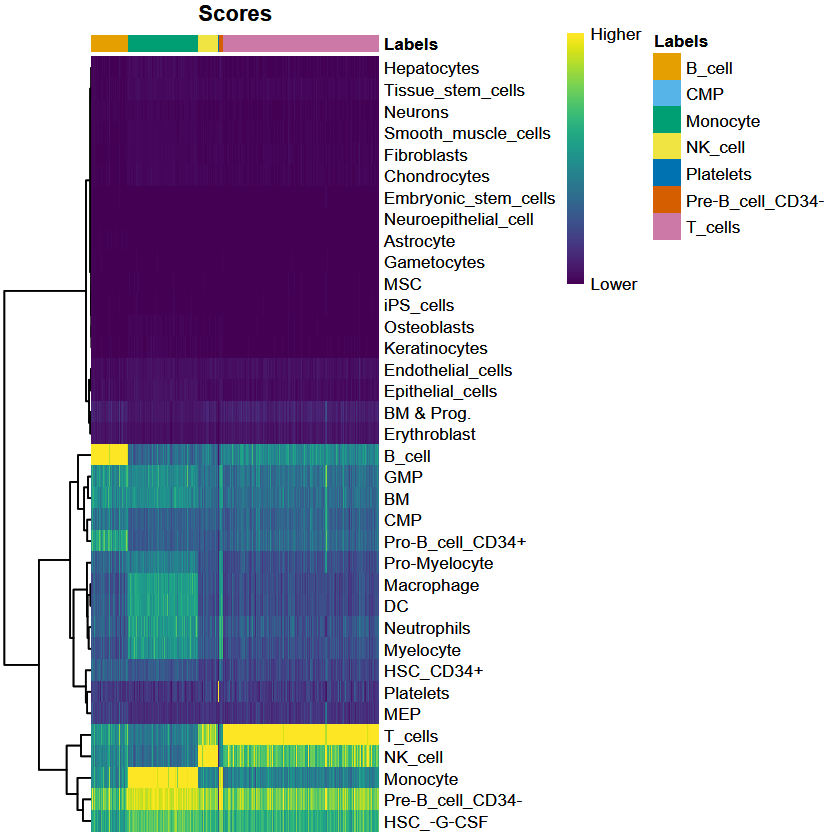

In [18]:
plotScoreHeatmap(pred_hesc)

In [19]:
pbmc_obj@meta.data$hesc_ids <- pred_hesc$labels # use the extensive labels

In [20]:
library(pheatmap)

Warning message:
"package 'pheatmap' was built under R version 4.4.3"


In [21]:
cluster_celltypes <- table(pbmc_obj$seurat_clusters, pbmc_obj$hesc_ids)

In [22]:
cluster_celltypes_log <- log1p(cluster_celltypes)

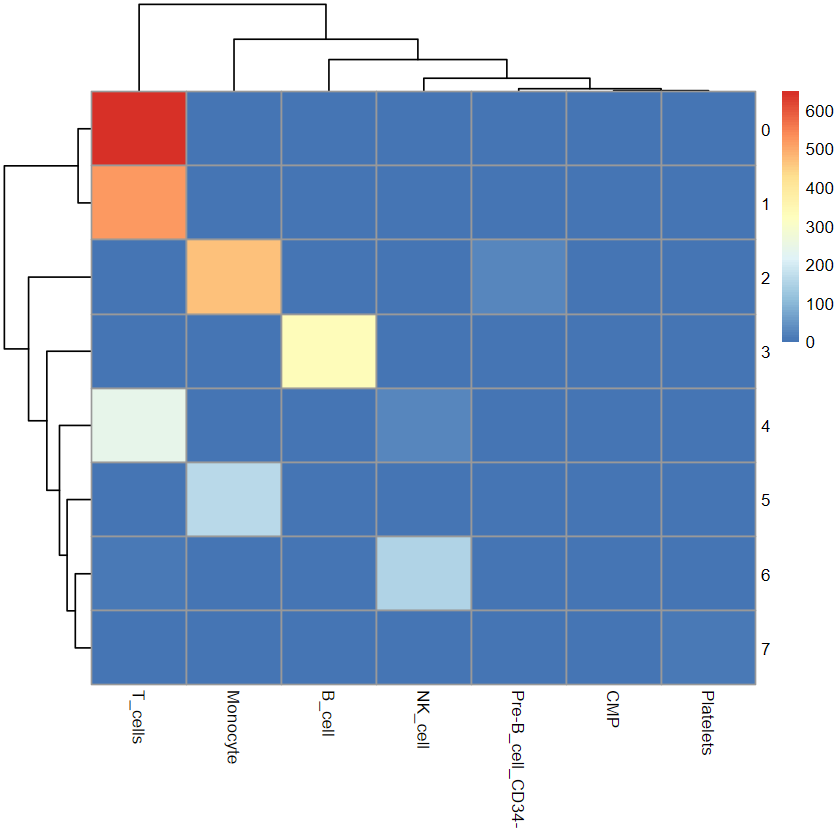

In [23]:
pheatmap(cluster_celltypes)

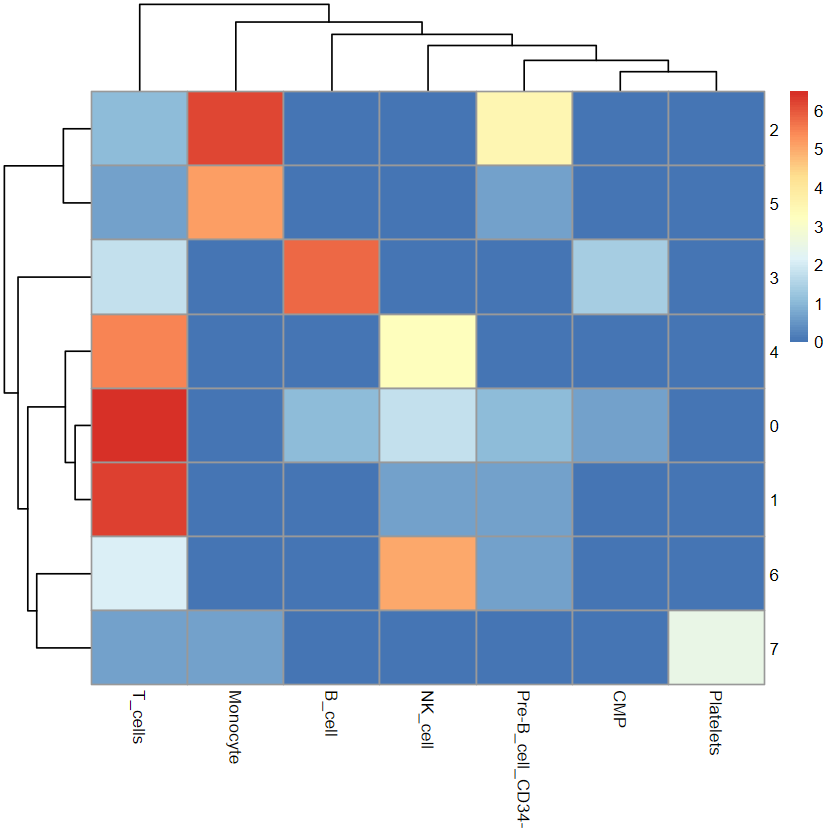

In [24]:
pheatmap(cluster_celltypes_log)

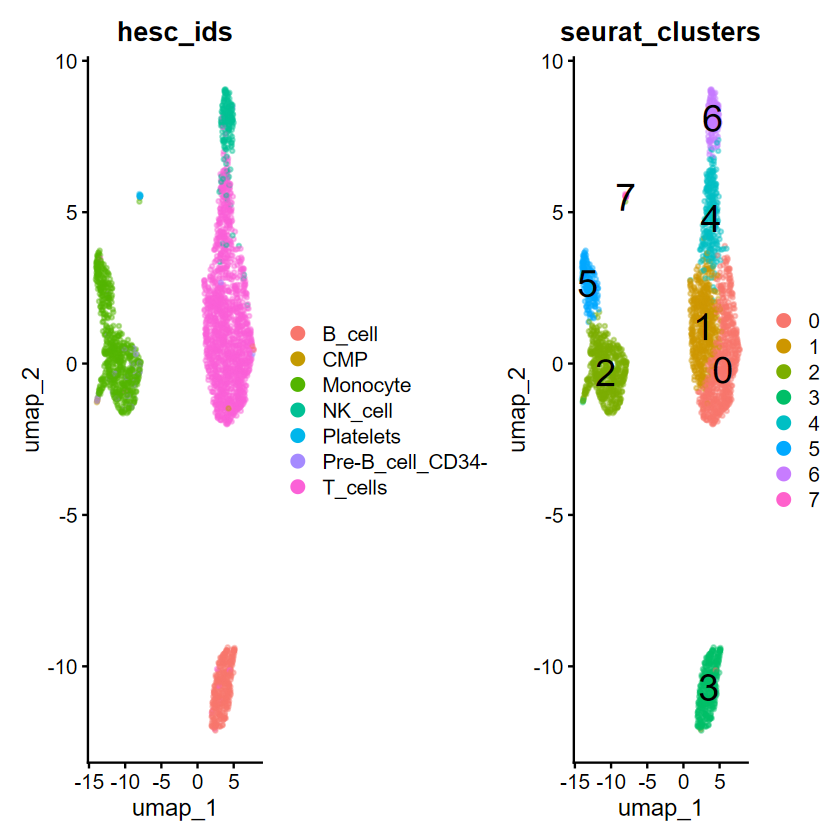

In [25]:
p1 <- DimPlot(object = pbmc_obj, group.by = 'hesc_ids', alpha = 0.4)
p2 <- DimPlot(object = pbmc_obj, group.by = 'seurat_clusters', label = TRUE, label.size = 8, alpha = 0.4)
p1 + p2

In [26]:
library(patchwork)  # for combining ggplots

Warning message:
"package 'patchwork' was built under R version 4.4.3"


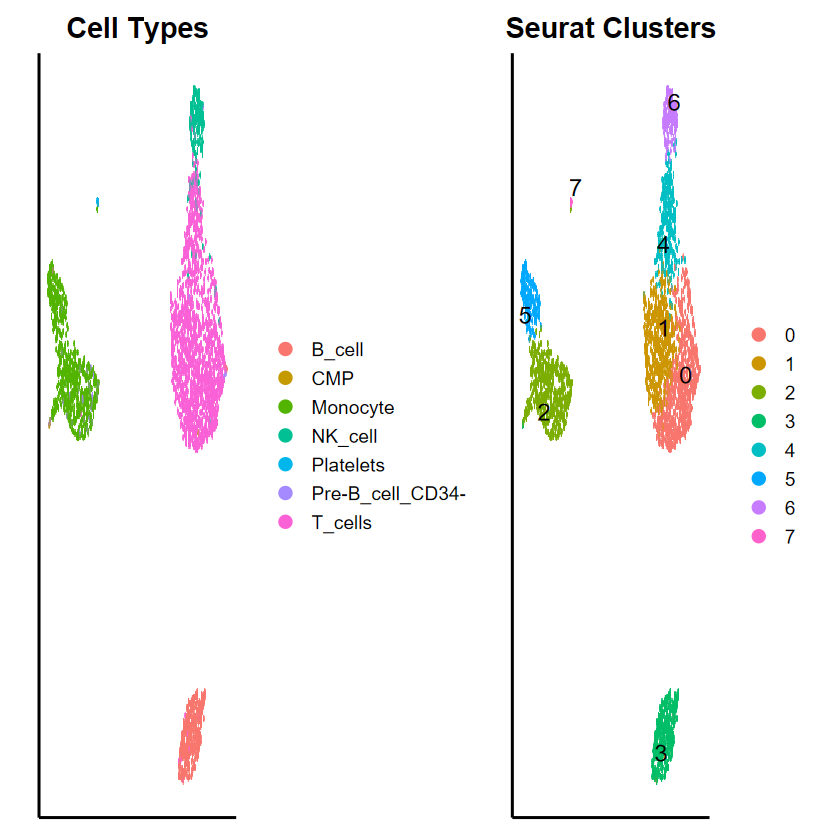

In [27]:
# UMAP: SingleR cell type annotation
p1 <- DimPlot(
  pbmc_obj,
  group.by = "hesc_ids",
  label = FALSE,
  repel = TRUE,
  pt.size = 3,         # slightly larger points
  raster = TRUE          # faster plotting for large data
) +
  ggtitle("Cell Types") +
  theme_classic(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )

# UMAP: Seurat cluster assignment
p2 <- DimPlot(
  pbmc_obj,
  group.by = "seurat_clusters",
  label = TRUE,
  repel = TRUE,
  label.size = 5,
  pt.size = 3,
  raster = TRUE
) +
  ggtitle("Seurat Clusters") +
  theme_classic(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    legend.position = "right"
  )

# Combine and adjust layout
combined_plot <- p1 + p2 +
  plot_layout(widths = c(1, 1)) &
  theme(
    plot.margin = margin(5, 10, 5, 10),
    axis.title = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank()
  )

# Display final figure
combined_plot


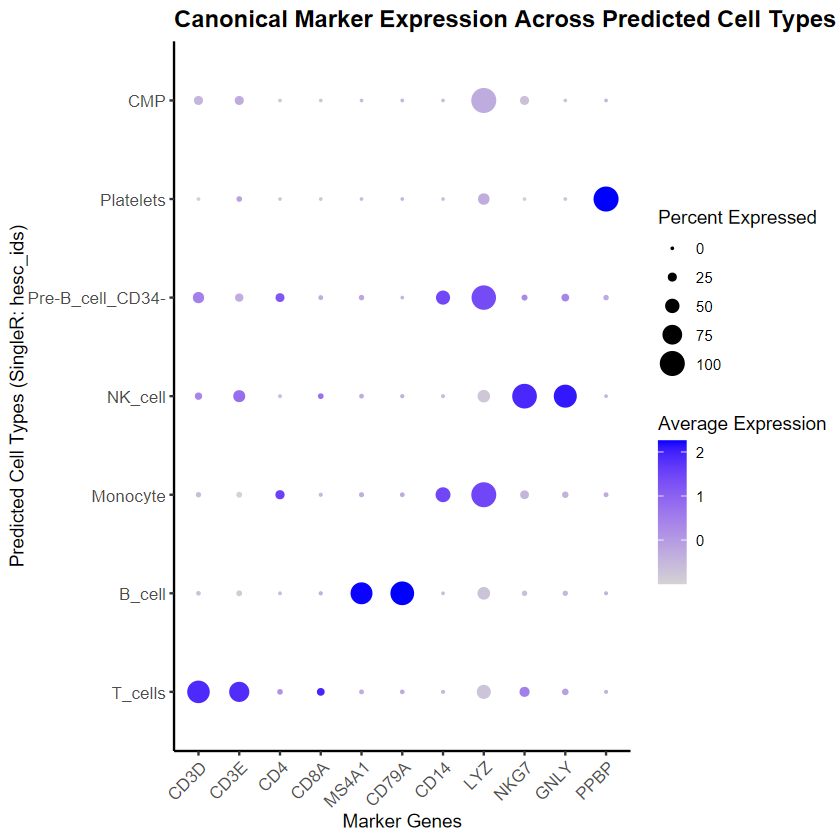

In [28]:
# Ensure the correct active identity
Idents(pbmc_obj) <- "hesc_ids"

# Create DotPlot grouped by SingleR cell type predictions
DotPlot(pbmc_obj, 
        features = c("CD3D", "CD3E", "CD4", "CD8A",   # T cells
                     "MS4A1", "CD79A",               # B cells
                     "CD14", "LYZ",                  # Monocytes
                     "NKG7", "GNLY",                 # NK cells
                     "PPBP"),                        # Platelets
        cols = c("lightgrey", "blue")) + 
  RotatedAxis() +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 10),
    axis.text.y = element_text(size = 10),
    plot.title = element_text(size = 14, face = "bold")
  ) +
  labs(title = "Canonical Marker Expression Across Predicted Cell Types",
       x = "Marker Genes",
       y = "Predicted Cell Types (SingleR: hesc_ids)")


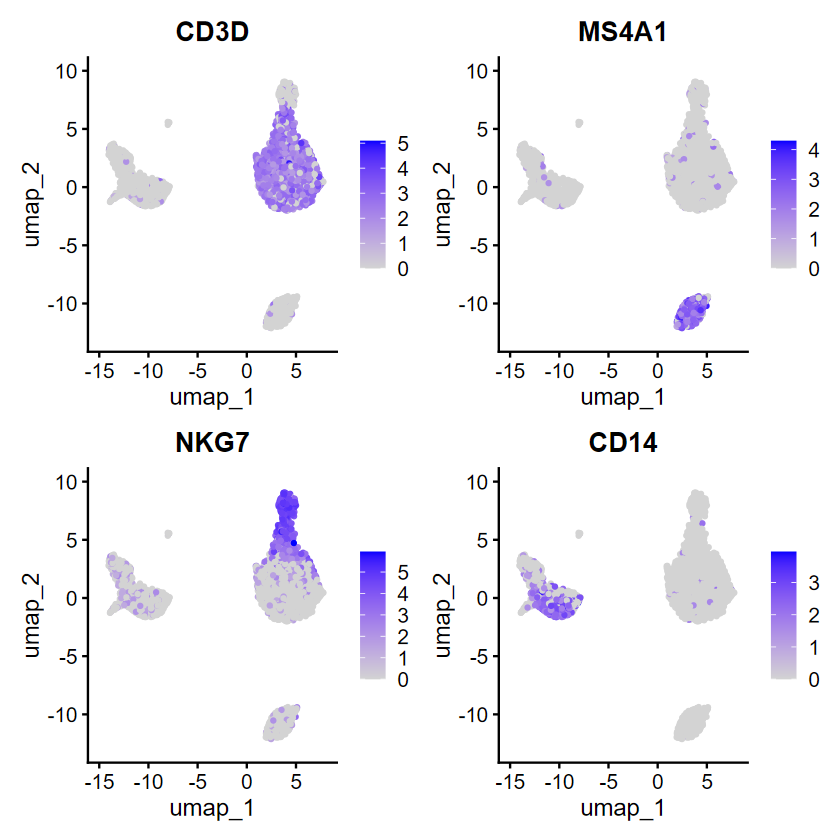

In [29]:
FeaturePlot(pbmc_obj, features = c("CD3D", "MS4A1", "NKG7", "CD14"))

In [30]:
blueprint <- celldex::BlueprintEncodeData() # another reference dataset
pred_bp <- SingleR(test = GetAssayData(pbmc_obj, slot="data"),
                   ref = blueprint,
                   labels = BlueprintEncodeData()$label.main)
head(pred_bp)

DataFrame with 6 rows and 4 columns
                                         scores       labels delta.next
                                       <matrix>  <character>  <numeric>
AAACATACAACCAC-1 0.217454:0.151028:0.331789:... CD8+ T-cells  0.2230408
AAACATTGAGCTAC-1 0.221720:0.129970:0.460009:...      B-cells  0.0582490
AAACATTGATCAGC-1 0.223236:0.139379:0.374722:... CD8+ T-cells  0.0235568
AAACCGTGCTTCCG-1 0.272346:0.130637:0.318908:...    Monocytes  0.0528113
AAACCGTGTATGCG-1 0.169636:0.123069:0.242714:...     NK cells  0.2889193
AAACGCACTGGTAC-1 0.228496:0.164083:0.338714:... CD8+ T-cells  0.1041801
                 pruned.labels
                   <character>
AAACATACAACCAC-1  CD8+ T-cells
AAACATTGAGCTAC-1       B-cells
AAACATTGATCAGC-1  CD8+ T-cells
AAACCGTGCTTCCG-1     Monocytes
AAACCGTGTATGCG-1      NK cells
AAACGCACTGGTAC-1  CD8+ T-cells

In [31]:
pbmc_obj$blueprint_ids <- pred_bp$labels

In [33]:
library(RColorBrewer)

In [37]:
library(grid)

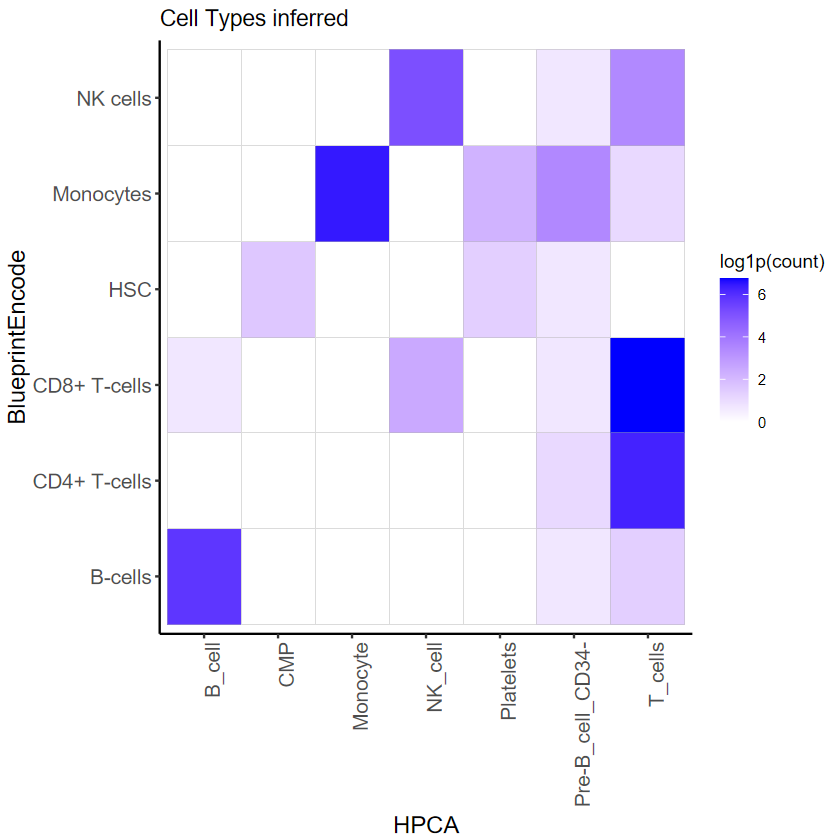

In [49]:
blueprint_hesc_table <- log1p(table(pbmc_obj$blueprint_ids, pbmc_obj$hesc_ids))

# Convert the table to a data frame for ggplot
df_heat <- as.data.frame(blueprint_hesc_table)
colnames(df_heat) <- c("BlueprintEncode", "HPCA", "Freq")

# Make sure it's in long format (if not already)
df_heat_long <- melt(df_heat, id.vars = c("BlueprintEncode", "HPCA"), value.name = "Freq")

# Plot the heatmap
ggplot(df_heat, aes(x = HPCA, y = BlueprintEncode, fill = Freq)) +
  geom_tile(color = "grey70") +
  scale_fill_gradient(low = "white", high = "blue", name = "log1p(count)") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title.x = element_text(size = 14, vjust = -0.5),
    axis.title.y = element_text(size = 14, vjust = 1.5)
  ) +
  labs(
    x = "HPCA",
    y = "BlueprintEncode",
    title = "Cell Types inferred"
  )

In [35]:
saveRDS(object = pbmc_obj, file = './pbmc_3k_data/pbmc_3k_annotated.RDS')